<a href="https://colab.research.google.com/github/aspurser84-dot/BIFX546-project/blob/main/notebooks/%20Final_project_BIFX546_Graham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Title: COVID-19 Variant tracking in California between 2021 through 2023

##Author: Amanda Graham

###Course: BIFX 546 — Machine Learning for Bioinformatics, Spring 2026

###Instructor: Dr. Sarangan (Ravi) Ravichandran

Date: 5/6/26

Disclaimer: This notebook was created as a final project for class. It uses a publicly available dataset, key concepts from BIFX 546 Machine Learning for Bioinformatics and concepts from the textbook Data Science from Scratch.

#Dataset name: COVID-19 Variant Data

The dataset is publicly available from the KaggleHub repository and contains COVID-19 variant data collected including date, area (California), area type (state), variant name, number of specimens collected, percentage of specimens collected, specimens 7 day average and the percentage 7 day average

###Source/URL: https://www.kaggle.com/datasets/nidzsharma/covid-19-variant-data

#Project Goal

###Can we predict the next circulating variant of COVID-19 based on a selection of features?

We hypothesize that there is typically one predominant circulating variant of COVID-19 during a time frame. Using a set of features such as the number of specimens collected, the percentage of specimens collected and the change in variant specimens collected per day and 7 day averages, we can predict the next predominant circulating variant.


# Installation requirements
The code below installs the required packages from the requirements file located in the Github repository.

In [ ]:
!pip install -r https://raw.githubusercontent.com/aspurser84-dot/BIFX546-project/main/requirements.txt

#Setting up directory

The code below changes the working directory so the data can be properly saved in Colab.

In [ ]:
import os

#Show current working directory
print("Old directory:", os.getcwd())

#Move up to main directory
os.chdir("/")

print("New directory:", os.getcwd())

Old directory: /content
New directory: /


#Upload the data
There are two options to upload the dataset into colab

1. Download the CSV file from the GitHub repository and upload it with the code below into CoLab:

In [ ]:
from google.colab import files
uploaded = files.upload()

2. Import the dataset from Kagglehub repository. This requires an API key setup in CoLab.

In [ ]:
#Imports the dataset from Kagglehub repository
#Places the dataset in kaggle/input/ folder
import kagglehub

#Download latest dataset
path = kagglehub.dataset_download("nidzsharma/covid-19-variant-data")

#Verify the actual data file is present, if not force re-download
csv_file = os.path.join(path, "covid19_variant.csv")

if not os.path.exists(csv_file):
  path = kagglehub.dataset_download("nidzsharma/covid-19-variant-data", force_download=True)

print("Path to dataset files:", path)

100%|██████████| 67.0k/67.0k [00:00<00:00, 6.79MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nidzsharma/covid-19-variant-data/versions/1


#Data overview

The code below converts the downloaded csv file to a pandas data frame. Then a quick summary is created for the following variables to calculate count, average, standard deviation, minimum, quantiles, and the maximum; specimens, percentage, specimens 7 day average, and percentage 7 day average,

This is important since we can see the number of specimens collected and percentage of specimens collected does not match the specimens 7 day average or percentage 7 day average. The specimens 7 day average and percentage 7 day average have missing values that will need to be calculated.

In [ ]:
#Converts csv file to pandas data frame
import pandas as pd

#Quick summary of dataset
df = pd.read_csv(csv_file)
df.describe()

,specimens,percentage,specimens_7d_avg,percentage_7d_avg
count,7790.000000,7790.000000,7730.000000,7730.000000
mean,177.596919,20.000004,178.622731,20.000000
std,485.649656,37.925758,449.876303,37.927537
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.142857,0.013672
75%,28.000000,7.380000,27.857143,7.414083
max,5802.000000,100.000000,3295.000000,100.000000


The code below provides value counts for the number of variants.

This shows there is also a 'Total' and 'Other' count in the 'variant_name'. These both will need to be removed when comparing individual variants.

In [ ]:
#Determine the number of variants
pd.Series(df["variant_name"]).value_counts()

,count
variant_name,
Alpha,779
Lambda,779
Other,779
Epsilon,779
Omicron,779
Beta,779
Total,779
Delta,779
Mu,779


The code below calculates summary statistics for each variant; median, average and standard deviation. It shows there are two variants that have a higher presence in the data, 'Delta' and 'Omicron'.

It also confirms the 'Total' variant is the combined value for all variants and this will need to be removed when comparing the different variants.

In [ ]:
#summary stats median, mean and standard deviation by variant type
df.groupby("variant_name")["specimens"].agg(["median", "mean", "std"])

,median,mean,std
variant_name,,,
Alpha,0.0,21.079589,48.532144
Beta,0.0,0.218228,0.868546
Delta,0.0,310.150193,654.710835
Epsilon,0.0,31.997433,98.848317
Gamma,0.0,4.747112,10.588784
Lambda,0.0,0.227214,0.855034
Mu,0.0,1.471117,5.580458
Omicron,241.0,491.812580,706.144161
Other,5.0,26.281130,55.751669


The code below determines if there are any N/A values.

It shows the specimens 7 day average and percentage7 day average have missing values. These will need to be calculated and filled in.

In [ ]:
#Determine if there are any N/A values
df.isna().sum()

,0
date,0
area,0
area_type,0
variant_name,0
specimens,0
percentage,0
specimens_7d_avg,60
percentage_7d_avg,60


The code below determines what data type each variable is. It shows the variable 'date' is an object and will need to be changed to date time data type.

In [ ]:
#Determine data types
df.dtypes

,0
date,object
area,object
area_type,object
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


The code below determines how many values are listed in the variable area. It shows there is only one value for 'area' (California). This variable will have to be removed since it does not provide information on other locations.

In [ ]:
#Counts for 'area' variable
pd.Series(df["area"]).value_counts()

,count
area,
California,7790


The code below determines how many values are listed in the variable 'area_type'. It shows there is only one value for 'area_type' (State). This variable will have to be removed since it does not provide information on other area types.

In [ ]:
#Counts for 'area_type'
pd.Series(df["area_type"]).value_counts()

,count
area_type,
State,7790


#Data Cleaning

The code below changes the 'date' variable to a date time data type.

This properly sorts the data by 'date' and allows the data to be properly graphed using seaborn.

In [ ]:
#Convert 'date' to date time data type
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df.dtypes

,0
date,datetime64[ns]
area,object
area_type,object
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


The code below removes the variables 'area' and 'area_type', as these only contain one value.

In [ ]:
#Removes 'area' and 'area_type' variables
df1 = df.copy()
df1 = df1.drop(columns=['area', 'area_type'])
df1.dtypes

,0
date,datetime64[ns]
variant_name,object
specimens,int64
percentage,float64
specimens_7d_avg,float64
percentage_7d_avg,float64


The code below sorts the data frame by 'date' and 'variant_name'. This allows visual verification of the 7 day average calculations.

In [ ]:
#sort data by variant and date
df1 = df1.sort_values(by= ['variant_name',"date"], ascending=True)
df1

,date,variant_name,specimens,percentage,specimens_7d_avg,percentage_7d_avg
0,2021-01-01,Alpha,1,1.69,NaN,NaN
10,2021-01-02,Alpha,6,5.56,NaN,NaN
20,2021-01-03,Alpha,5,1.87,NaN,NaN
31,2021-01-04,Alpha,5,0.40,NaN,NaN
42,2021-01-05,Alpha,16,1.97,NaN,NaN
...,...,...,...,...,...,...
7747,2023-02-14,Total,87,100.00,118.285714,100.0
7754,2023-02-15,Total,176,100.00,115.857143,100.0
7760,2023-02-16,Total,148,100.00,110.142857,100.0
7773,2023-02-17,Total,40,100.00,95.142857,100.0


The code below calculates the rolling 7 day average for both 'specimens' and 'percentage'. The data frame must be sorted by 'variant' and 'date' before calculating these averages to get a correct 7 day average.

In [ ]:
#Calculate 7-day rolling average
#specimens_7d_avg
data_sorted = df1.sort_values(by= ['variant_name',"date"], ascending=True)
series_specimen = pd.Series(data_sorted['specimens'])

moving_avg_specimens = series_specimen.rolling(window=7).mean()

#Percentage_7d_avg
data = df1['percentage'].tolist()
series_percentage = pd.Series(data_sorted['percentage'])

moving_avg_percentage = series_percentage.rolling(window=7).mean()

The code below fills in the values with the calculated rolling 7 day average for both specimens and percentage.

Since the first 6 days cannot calculate a 7 day average these must be filled in with a value of zero using .fillna(0).

In [ ]:
#Fill in values with 7 day average
df2 = df1.copy()
df2['specimens_7d_avg'] = moving_avg_specimens
df2['percentage_7d_avg'] = moving_avg_percentage

#Fill in N/A values
df2['specimens_7d_avg'] = df2['specimens_7d_avg'].fillna(0)
df2['percentage_7d_avg'] = df2['percentage_7d_avg'].fillna(0)

The code below confirms all N/A values are filled in.

In [ ]:
#Verify N/A values were filled in
df2.isna().sum()

,0
date,0
variant_name,0
specimens,0
percentage,0
specimens_7d_avg,0
percentage_7d_avg,0


The code below removes all rows with 'Total' and 'Other' as the variant name.

In [ ]:
#Remove all rows with "Total" and 'Other' in variant_name
A_value_to_remove = 'Total'
B_value_to_remove = 'Other'

df2 = df2[df2['variant_name'] != A_value_to_remove]
df2 = df2[df2['variant_name'] != B_value_to_remove]

#Verifies values were removed
pd.Series(df2["variant_name"]).value_counts()

,count
variant_name,
Alpha,779
Beta,779
Delta,779
Epsilon,779
Gamma,779
Lambda,779
Mu,779
Omicron,779


The code below calculates the rate in change for number of specimens per day by variant. It is important to group the data by variant name so the change can be properly calculated. It also fills in the first value of rate change with zero since this can't be calculated.

In [ ]:
#Calculates the rate change for number of specimens per day
rate_change = df2.groupby('variant_name', as_index=False)['specimens'].diff()
df3 = df2.copy()
df3['rate_change'] = rate_change

#Fills in the N/A values with zero
df3['rate_change'] = df3['rate_change'].fillna(0)


The code below calculates the 7 day average for rate change and fills in the first 6 values with zero. The data frame must be sorted by 'variant' and 'date' to properly calculate a 7 day average.

In [ ]:
#Calculate 7-day rolling average
#Rate change
data_sorted2 = df3.sort_values(by= ['variant_name',"date"], ascending=True)
series_rate = pd.Series(data_sorted2['rate_change'])
moving_avg_rate = series_rate.rolling(window=7).mean()

#Fill in values
df3['rate_change_7d_avg'] = moving_avg_rate
df3['rate_change_7d_avg'] = df3['rate_change_7d_avg'].fillna(0)

The code below removes any rows where there were no specimens collected.

In [ ]:
# Remove rows where there were no specimens collected
df4 = df3.copy()

#Value to drop from a specific column
threshold = 1

#Drop rows where the column matches the value
df5 = df4[df4['specimens'] >= 1].reset_index(drop=True)
df5 = df5.sort_values(by= ['variant_name',"date"], ascending=True)

print("The original dataset contained", df4.shape, "rows and columns.")
print("The new dataset contains", df5.shape, "rows and columns.")

The original dataset contained (6232, 8) rows and columns.
The new dataset contains (1797, 8) rows and columns.


#Data Visualization

The code below creates a file path to export the cleaned data frame as a CSV and the following images.

In [ ]:
#File path (can include folders)
file_path = "output/data.csv"

try:
    #Ensure the directory exists
    os.makedirs(os.path.dirname(file_path), exist_ok=True)

    #Exports clean DataFrame to CSV
    df5.to_csv(file_path, index=False, encoding="utf-8")

    print(f"DataFrame successfully exported to '{file_path}'")
except PermissionError:
    print("Error: Permission denied. Please check file permissions.")
except FileNotFoundError:
    print("Error: Invalid file path.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

DataFrame successfully exported to 'output/data.csv'


##Distribution of Variants

The code below creates a box plot for the number of specimens collected per variant.

It shows there are two variants with a higher number of specimens present, 'Delta' and 'Omicron'.

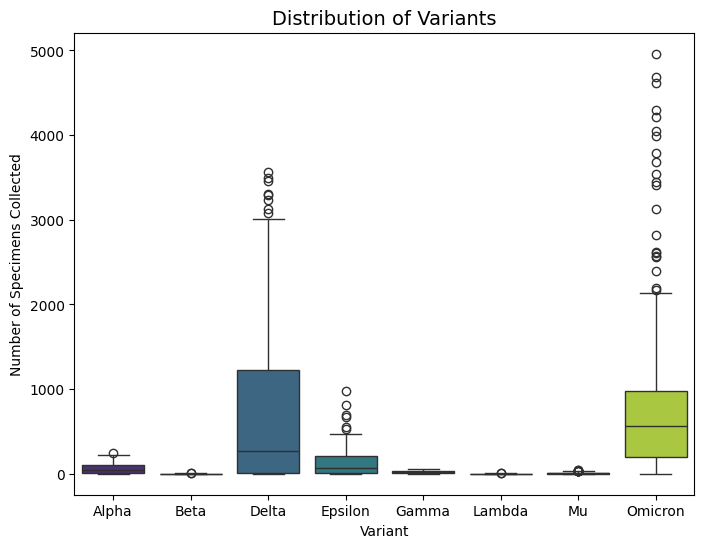

In [ ]:
#Boxplot of number of specimens collected per variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
box_plot = sns.boxplot(
    data=df5,
    x="variant_name",
    y="specimens",
    hue="variant_name",   #Color by category
    palette="viridis",    #Color palette
    legend=False          #Removes ledgend
)

#Add labels and title
plt.title("Distribution of Variants", fontsize=14)
plt.xlabel("Variant")
plt.ylabel("Number of Specimens Collected")

#Display plot
plt.show()

#Save as png
fig = box_plot.get_figure()
fig.savefig('output/Fig1_Distribution_of_Variants.png')

##Number of Specimens Collected Over Time by Variant

The code below graphs the number of specimens collected over time by variant. It shows the variant 'Delta' starts to be present about 07/2021 and is the main variant present until about 01/2022. Then both variants 'Delta' and 'Omicron' are present for a short time until the variant 'Omicron' is the main variant until about 01/2023. Most of the other variants are present in low abundance.

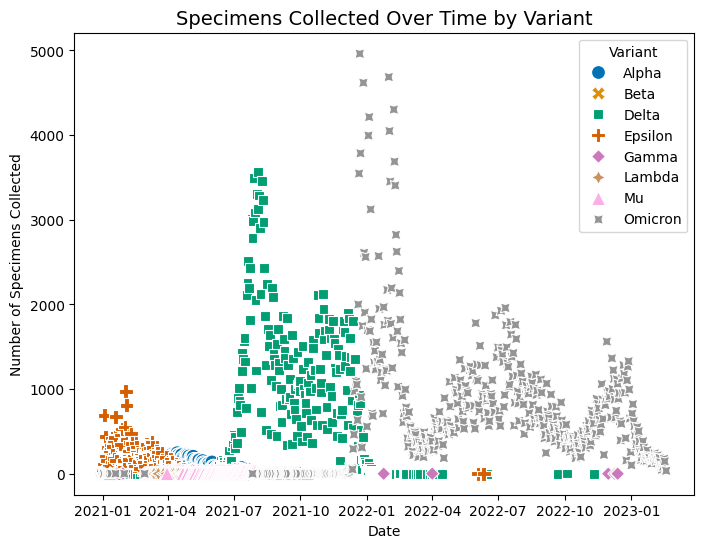

In [ ]:
#XY scatter plot number of specimens collected over time by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
count_plot = sns.scatterplot(
    data=df5,
    x= "date",
    y="specimens",
    hue="variant_name",   #Color by category
    style="variant_name", #Different marker styles
    s=100,            #Marker size
    palette="colorblind"    #Color palette
)

#Add labels and title
plt.title("Specimens Collected Over Time by Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Number of Specimens Collected")
plt.legend(title="Variant")

#Display plot
plt.show()

#Save as png
fig = count_plot.get_figure()
fig.savefig('output/Fig2_Specimens_Collected_Over_Time.png')

##Percentage of Variants Over Time
The code below graphs the percentage of variants over time.

This graph better shows the low abundance variants as a mixed population between 01/2021 through 07/2021. Between 01/2021 and 04/2021 it shows 'Epsilon' and 'Other' variants being the predominant variants present. Then between 04/2021 and 07/2021 it shows 'Alpha' is the predominant variant present with the other variants still present in low abundance. Then it shows 'Delta', the predominant variant present. 'Delta' then decreases as 'Omicron' increases and this becomes the predominant variant present.

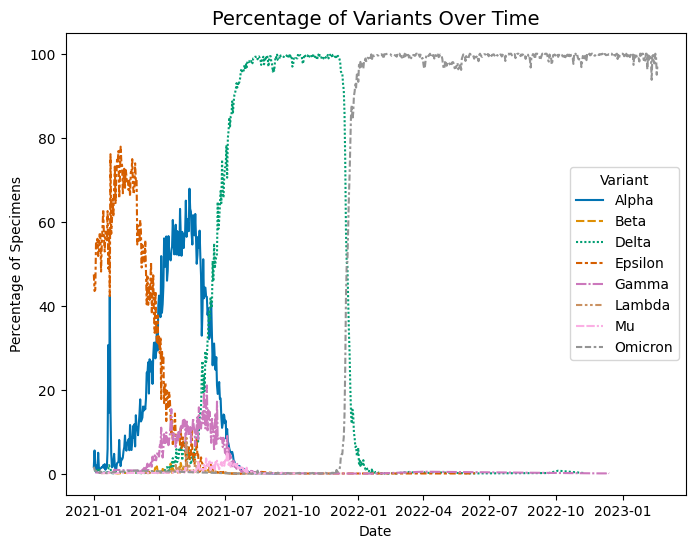

In [ ]:
#Line plot percentage collected over time by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
percentage_plot = sns.lineplot(
    data=df5,
    x="date",
    y="percentage",
    hue="variant_name",   #Color by category
    style="variant_name", #Different marker styles
    palette="colorblind"    #Color palette
)

#Add labels and title
plt.title("Percentage of Variants Over Time", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Percentage of Specimens")
plt.legend(title="Variant")

#Display plot
plt.show()

#Save as png
fig = percentage_plot.get_figure()
fig.savefig('output/Fig3_Percentage_Variants_Over_Time.png')

##Rate of Change per Variant

The code below graphs the rate of change per variant over time.

This shows 'Delta' and 'Omicron' have a higher rate change comparred to the other variants detected. It also shows the highest rate changes occur in the beginning presence of both variants.

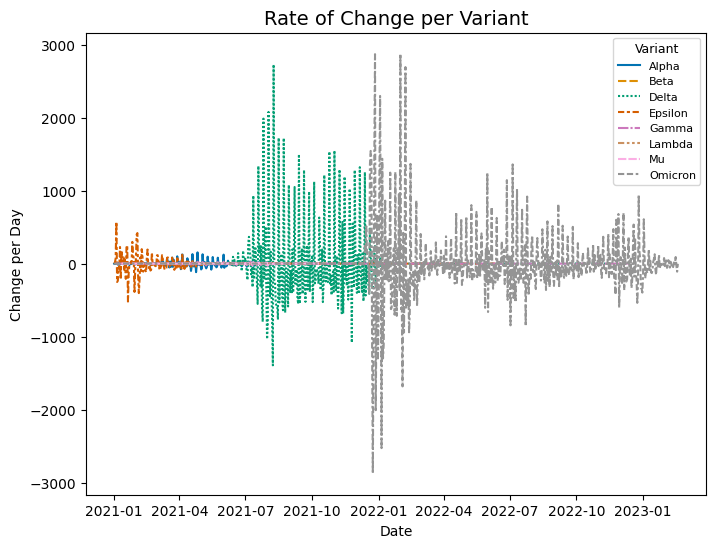

In [ ]:
#Line plot rate of change by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
change_plot = sns.lineplot(
    data= df5,
    x="date",
    y="rate_change",
    hue="variant_name",   #Color by category
    style="variant_name", #Different marker styles
    palette="colorblind"    #Color palette
)

# Add labels and title
plt.title("Rate of Change per Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Change per Day")
plt.legend(title="Variant", fontsize=8, title_fontsize=9, markerscale=0.7)

#Display plot
plt.show()

#Save as png
fig = change_plot.get_figure()
fig.savefig('output/Fig4_Rate_of_Change_per_Variant.png')

##7 Day Rate of Change per Variant

The code below graphs the 7 day rate of change per variant over time.

This graph normalizes the data to better show the average rate change for a 7 day period and it shows 'Omicron' has the highest average rate change out of all variants.

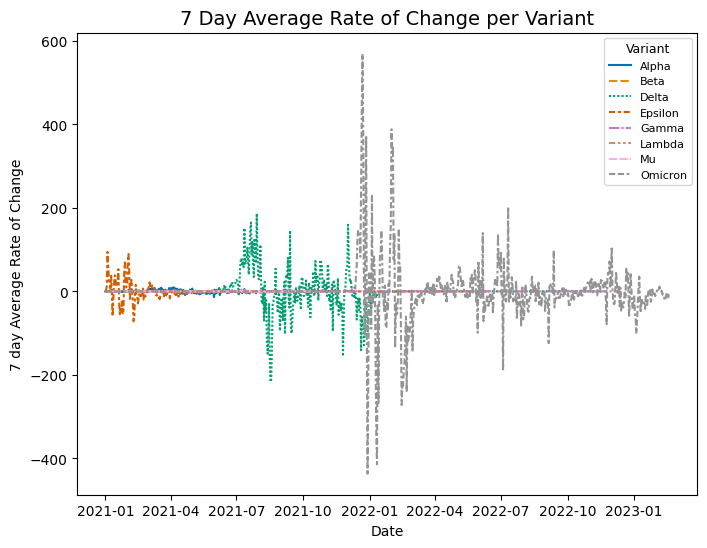

In [ ]:
#Line plot 7day rate of change by variant
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
change_plot = sns.lineplot(
    data= df5,
    x="date",
    y="rate_change_7d_avg",
    hue="variant_name",   #Color by category
    style="variant_name", #Different marker styles
    palette="colorblind"    #Color palette
)

#Add labels and title
plt.title("7 Day Average Rate of Change per Variant", fontsize=14)
plt.xlabel("Date")
plt.ylabel("7 day Average Rate of Change")
plt.legend(title="Variant", fontsize=8, title_fontsize=9, markerscale=0.7)

#Display plot
plt.show()

#Save as png
fig = change_plot.get_figure()
fig.savefig('output/Fig5_Average_Rate_of_Change_per_Variant.png')

#Random Forest Model
The code below sets a threshold for the variable 'percentage' to >= 1 and removes any rows below this threshold.

In [ ]:
# Set a threshold for variables
df6= df5.copy()

# Value to drop from a specific column
threshold = 1

# Drop rows where the column matches the value
df7 = df6[df6['percentage'] >= threshold].reset_index(drop=True)

df7.groupby("variant_name")["specimens"].agg(["min", "max", "median", "mean", "std"])

,min,max,median,mean,std
variant_name,,,,,
Alpha,1,249,64.5,80.745000,66.152405
Beta,1,8,5.0,5.166667,2.037527
Delta,1,3569,731.0,856.056738,847.355285
Epsilon,1,974,112.0,156.427673,168.923526
Gamma,6,58,27.0,25.215385,11.250485
Lambda,2,10,5.0,4.909091,2.427120
Mu,1,41,8.5,14.766667,12.441547
Omicron,1,4961,662.0,870.286364,744.164067


The code below encodes variant names to numeric values using a dictionary. This encoding allows the model to be properly trained. These values can then be called back using the dictionary 'encoder_list' to see the variant names predicted.

In [ ]:
#Encode catagorical values to numeric
#Needed to preform scalar fit transform
encoder_list = df7['variant_name'].unique()
encoder_values = [i for i in range(len(encoder_list))]
encoder_dict = dict(zip(encoder_list, encoder_values))
df7['variant_name'] = df7['variant_name'].map(encoder_dict)
pd.Series(df7["variant_name"]).value_counts()
print(encoder_list, encoder_values)


['Alpha' 'Beta' 'Delta' 'Epsilon' 'Gamma' 'Lambda' 'Mu' 'Omicron'] [0, 1, 2, 3, 4, 5, 6, 7]


In [ ]:
from sklearn.model_selection import train_test_split
#Parts of this code were created using Gemini

df_sorted = df7.sort_values(by='date')

#Identify classes with only one member in df_sorted
#credit Gemini
class_counts = df_sorted['variant_name'].value_counts()
single_member_classes = class_counts[class_counts == 1].index

#Filter out rows belonging to single-member classes
#credit Gemini
if not single_member_classes.empty:
    df_sorted = df_sorted[~df_sorted['variant_name'].isin(single_member_classes)].copy()
    print(f"Removed single-member classes from df_sorted: {list(single_member_classes)}")
else:
    print("No single-member classes found to remove.")

y = df_sorted['variant_name'] #Extract the target variable 'variant_name'
X = df_sorted.drop(columns=['date', 'variant_name']) #Extract features (dropping date and variant_name)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

feature_names = X_train.columns.tolist()

print(f'X Training set : {X_train.shape[0]} samples')
print(f'X Test set     : {X_test.shape[0]} samples')

No single-member classes found to remove.
X Training set : 1035 samples
X Test set     : 259 samples


The code below provides a class distribution for the training dataset. It shows the variants are not evenly represented in the training data with a range from 0.9-34% distribution.

In [ ]:
import numpy as np
unique, counts = np.unique(y_train, return_counts=True)
print("Training set class distribution:")
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls}: {cnt} samples ({cnt/len(y_train)*100:.1f}%)")

Training set class distribution:
  Class 0: 160 samples (15.5%)
  Class 1: 10 samples (1.0%)
  Class 2: 225 samples (21.7%)
  Class 3: 127 samples (12.3%)
  Class 4: 104 samples (10.0%)
  Class 5: 9 samples (0.9%)
  Class 6: 48 samples (4.6%)
  Class 7: 352 samples (34.0%)


The below code calculates the computed weights per class. The highest weight is with class 5 which had the lower distribution in the training dataset.

In [ ]:
# Show the computed weights
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight('balanced',
                               classes=np.unique(y_train), y=y_train)
print("Computed class weights:")
for cls, w in zip(np.unique(y_train), weights):
    print(f"  Class {cls}: {w:.2f}")
print(f"\nRatio: minority gets {weights[1]/weights[0]:.1f}x more weight than majority")

Computed class weights:
  Class 0: 0.81
  Class 1: 12.94
  Class 2: 0.57
  Class 3: 1.02
  Class 4: 1.24
  Class 5: 14.38
  Class 6: 2.70
  Class 7: 0.37

Ratio: minority gets 16.0x more weight than majority


The code below builds a Random Forest model with a balanced class weight and starts with 100 trees. This model has 100% training accuracy and out of bag (OOB) score of 76.6%.

In [ ]:
#Create a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, criterion='entropy', oob_score=True,
                             class_weight='balanced',
                             random_state=42)

feature_names = X_train.columns.tolist()

#Fit the model
clf.fit(X_train, y_train)

print(f"Training accuracy : {clf.score(X_train, y_train):.0%}")
print(f"OOB score (≈ test): {clf.oob_score_:.2%}")
print("The Random Forest model was trained on the following features:", feature_names)

Training accuracy : 100%
OOB score (≈ test): 76.62%
The Random Forest model was trained on the following features: ['specimens', 'percentage', 'specimens_7d_avg', 'percentage_7d_avg', 'rate_change', 'rate_change_7d_avg']


The code below tests if adding additional trees would change the OOB score. Adding additional trees above 100 does not increase the OOB score and will probably not affect testing accuracy.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

n_trees_range = [1, 5, 10, 20, 50, 100, 200]

print(f"{'n_estimators':<15} {'OOB Score':>10}")
print('-' * 28)

for n in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n, criterion='entropy', oob_score=True, max_features='sqrt',random_state=42)
    rf.fit(X_train, y_train)
    print(f"{n:<15} {rf.oob_score_:>10.0%}")

n_estimators     OOB Score
----------------------------
1                      33%
5                      59%
10                     71%


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


20                     73%
50                     75%
100                    76%
200                    76%


The code below graphs the model OOB score based on adding additional trees.

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


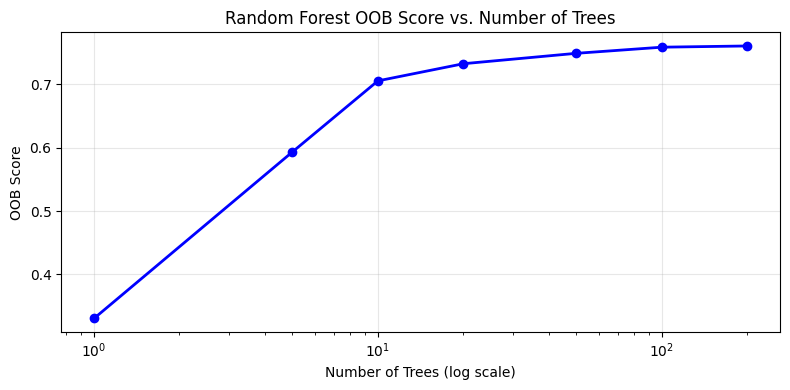

In [ ]:
# Show how OOB score improves as we add more trees
n_trees_range = [1, 5, 10, 20, 50, 100, 200]
oob_scores = []

for n in n_trees_range:
    rf_n = RandomForestClassifier(n_estimators=n, criterion='entropy',
                                   oob_score=True, random_state=42)
    rf_n.fit(X_train, y_train)
    oob_scores.append(rf_n.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(n_trees_range, oob_scores, 'o-', color='blue', lw=2)
plt.xscale('log')
plt.xlabel('Number of Trees (log scale)')
plt.ylabel('OOB Score')
plt.title('Random Forest OOB Score vs. Number of Trees')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The code below uses the model to make predictions on the variant based on the features. It also provides metrics for the model including the classification report breakdown, testing accuracy, precision, recall and the f1 score. Testing accuracy, precision, recall and the f1 score are all above 76%. The classification report provides additional information on the individual variant’s precision, recall and the f1 scores which had macro averages above 59% and weighted averages above 70%. There was one variant 'Beta' which had precision, recall and the f1 scores at 0. However, this variant only had 2 samples present in the testing dataset.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

#Make predictions
y_pred = clf.predict(X_test)

variant_name = encoder_list

#support number of samples
print(classification_report(y_test, y_pred, labels= encoder_values, target_names= variant_name, zero_division=0))
#Accuracy, all predictions correct
accuracy = accuracy_score(y_test, y_pred)
print(f"Testing accuracy: {accuracy:.2%}")

#Precision, true positives correctly called
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Precision: {precision:.2%}")

#Recall, true positive rate
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"Recall: {recall:.2%}")

#F1 score, model accuracy balanced
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
print(f"F1 Score: {f1:.2%}")

              precision    recall  f1-score   support

       Alpha       0.68      0.75      0.71        40
        Beta       0.00      0.00      0.00         2
       Delta       0.70      0.74      0.72        57
     Epsilon       0.81      0.66      0.72        32
       Gamma       0.71      0.77      0.74        26
      Lambda       0.33      0.50      0.40         2
          Mu       0.56      0.75      0.64        12
     Omicron       0.94      0.85      0.89        88

    accuracy                           0.76       259
   macro avg       0.59      0.63      0.60       259
weighted avg       0.78      0.76      0.77       259

Testing accuracy: 76.45%
Precision: 77.80%
Recall: 76.45%
F1 Score: 76.84%


The code below shows each feature that the model was trained on and how important that feature is in predicting the variant. The highest features are specimens 7 day average, percentage 7 day average and percentage.

In [ ]:
# Feature importances
print("Feature importances (Random Forest):")
for name, imp in sorted(zip(feature_names, clf.feature_importances_), key=lambda x: -x[1]):
    bar = '█' * int(imp * 40)
    print(f"  {name:8s}: {imp:.2%}  \n {bar}")

Feature importances (Random Forest):
  percentage_7d_avg: 29.31%  
 ███████████
  specimens_7d_avg: 25.39%  
 ██████████
  percentage: 18.15%  
 ███████
  specimens: 12.77%  
 █████
  rate_change_7d_avg: 7.60%  
 ███
  rate_change: 6.78%  
 ██


##Confusion matrix
The code below graphs the actual values versus predicted values as a confusion matrix. While the model is good at predicting actual variants there are some misclassified variants.

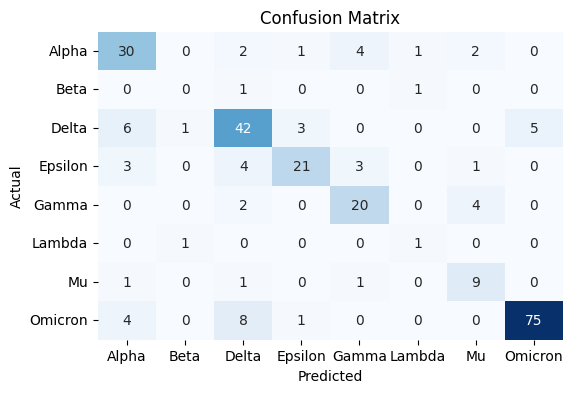

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
variant_name = encoder_list

true_labels =y_test
predicted_labels = y_pred
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(6,4))
sns.heatmap(cm,
annot=True,
fmt='d',
cmap='Blues',
cbar=False,
xticklabels= variant_name,
yticklabels= variant_name)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

#Save as png
fig = change_plot.get_figure()
fig.savefig('output/Fig6_Confusion_Matrix.png')


##Random Forest Threshold 1% Results:
Setting a cutoff threshold to remove variants with percentage values less than 1% increases the testing accuracy to 76%. While this model cannot accurately predict low levels of other variants (less than 1% of the population) it can predict the next predominant variant once it reaches over 1% of the population. This threshold can be increased up to 30% which will increase the testing accuracy, precision, recall and the f1 score up to 90% however, this removes variants present in low abundance.

#Conclusion

Using a Random Forest model with a threshold cutoff on the variable 'percentage' proves to be the best Random Forest model. The original model training accuracy reached 100% but the OOB score was low at 76.6% with a testing accuracy at 76%. Adding additional trees did not have much of an impact on the OOB score. The most important factor for the model was stratifying the splitting so that there was a larger distribution of all variants present in the training and testing dataset. Splitting the dataset using time series split proved to limit the testing dataset to only four variants present (see supplemental notebook). This threshold cutoff allowed all eight variants to be trained and tested on. However, it is possible to increase this threshold cutoff to 30% which increases the testing accuracy, precision, recall and f1 score up to 90% however, this comes at a cost of removing variants present in low abundance and only four variants would be found in the testing and training dataset.